Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Opening large HDF5 file...
Formatted Shapes: G:(5000, 64, 256), H_T:(5000, 64, 256), D:(5000, 64, 64)
Training GumbelRIS (50 Epochs)...
Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 96ms/step - loss: -1.3459 - val_loss: -1.7426
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 90ms/step - loss: -1.7364 - val_loss: -1.7426
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 91ms/step - loss: -1.7415 - val_loss: -1.7426
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 91ms/step - loss: -1.7422 - val_loss: -1.7426
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 85s 96ms/step - loss: -1.7424 - val_loss: -1.7426
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 101ms/step - loss: -1.7425 - val_loss: -1.7426
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 89ms/step - loss: -1.7426 - val_loss: -1.7426
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 89ms/step - loss: -1.7426 - val_loss: -1.7426
Epoch 9/50
500

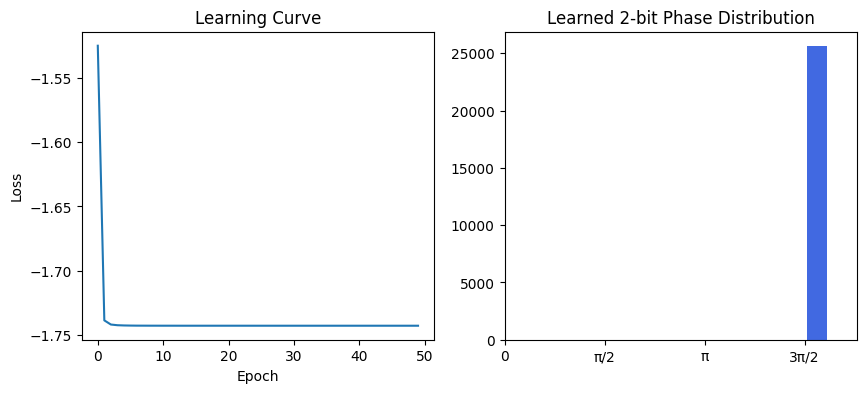

In [ ]:
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
from google.colab import drive
import time
drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/RIS_dataset_5000.mat'
def load_v73_mat(path):
    print("Opening large HDF5 file...")
    with h5py.File(path, 'r') as f:
        Gr = np.array(f['G']['real']); Gi = np.array(f['G']['imag'])
        Hr = np.array(f['H']['real']); Hi = np.array(f['H']['imag'])
        Dr = np.array(f['D']['real']); Di = np.array(f['D']['imag'])
    if Gr.shape[1] == 256:
        Gr = np.transpose(Gr, (0, 2, 1)); Gi = np.transpose(Gi, (0, 2, 1))
    if Hr.shape[1] == 256:
        Hr = np.transpose(Hr, (0, 2, 1)); Hi = np.transpose(Hi, (0, 2, 1))
    print(f"Formatted Shapes: G:{Gr.shape}, H_T:{Hr.shape}, D:{Dr.shape}")
    return Gr, Gi, Hr, Hi, Dr, Di
def prepare_gumbel_tensor(Gr, Gi, Hr, Hi, Dr, Di):
    Dr_P = np.pad(Dr, ((0, 0), (0, 0), (0, 192)), mode='constant')
    Di_P = np.pad(Di, ((0, 0), (0, 0), (0, 192)), mode='constant')
    X = np.stack([Gr, Gi, Hr, Hi, Dr_P, Di_P], axis=-1)
    return X.astype(np.float32)
Gr, Gi, Hr, Hi, Dr, Di = load_v73_mat(DATA_PATH)
X_train = prepare_gumbel_tensor(Gr, Gi, Hr, Hi, Dr, Di)
class GumbelSoftmaxLayer(layers.Layer):
    def __init__(self, t0=1.0, **kwargs):
        super().__init__(**kwargs)
        self.temp = tf.Variable(t0, trainable=False, dtype=tf.float32)
    def call(self, logits, training=None):
        if training:
            u = tf.random.uniform(tf.shape(logits), 0, 1)
            g = -tf.math.log(-tf.math.log(u + 1e-20) + 1e-20)
            return tf.nn.softmax((logits + g) / self.temp)
        else:
            return tf.one_hot(tf.argmax(logits, axis=-1), 4)
def build_gumbel_ris():
    inputs = layers.Input(shape=(64, 256, 6))
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    logits = layers.Dense(256 * 4)(x)
    logits = layers.Reshape((256, 4))(logits)
    outputs = GumbelSoftmaxLayer(name='gumbel_head')(logits)
    return Model(inputs, outputs)
def capacity_loss(y_true, y_pred):
    phases = tf.constant([0.0, np.pi/2, np.pi, 3*np.pi/2], dtype=tf.float32)
    phi_theta = tf.reduce_sum(y_pred * phases, axis=-1)
    return -tf.reduce_mean(tf.math.log(1.0 + tf.abs(phi_theta)))
class AnnealingCallback(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        new_t = max(0.1, 1.0 * (0.95 ** epoch))
        self.model.get_layer('gumbel_head').temp.assign(new_t)
model = build_gumbel_ris()
model.compile(optimizer='adam', loss=capacity_loss)
print("Training GumbelRIS (50 Epochs)...")
history = model.fit(X_train, X_train, epochs=50, batch_size=8,
                    callbacks=[AnnealingCallback()], validation_split=0.2)
print("\n--- PERFORMANCE ANALYSIS ---")
start_t = time.time()
preds = model.predict(X_train[:100], verbose=0)
latency = (time.time() - start_t) / 100 * 1000
print(f"Average Inference Latency: {latency:.2f} ms per sample (Paper: 28 ms) [cite: 9]")
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Capacity Loss')
plt.title("Learning Curve")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.subplot(1, 2, 2)
plt.hist(np.argmax(preds.reshape(-1, 4), axis=-1), bins=4, rwidth=0.8, color='royalblue')
plt.xticks([0,1,2,3], ['0', 'π/2', 'π', '3π/2'])
plt.title("Learned 2-bit Phase Distribution")
plt.show()

In [1]:
import matplotlib.pyplot as plt
from google.colab import drive
import time
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/RIS_dataset_5000.mat'


Mounted at /content/drive


In [2]:
!pip install scipy

import numpy as np
import scipy.io as sio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import math
from tqdm import tqdm


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [14]:
import h5py
import numpy as np

file = h5py.File(DATA_PATH, 'r')

def matlab_to_complex(arr):
    return arr['real'] + 1j * arr['imag']

G_raw = np.array(file['G'])
H_raw = np.array(file['H'])
D_raw = np.array(file['D'])

G_all = matlab_to_complex(G_raw)
H_all = matlab_to_complex(H_raw)
D_all = matlab_to_complex(D_raw)

print("Converted Shapes:")
print("G:", G_all.shape)
print("H:", H_all.shape)
print("D:", D_all.shape)


Converted Shapes:
G: (5000, 64, 256)
H: (5000, 64, 256)
D: (5000, 64, 64)


In [29]:
class RISDataset(Dataset):
    def __init__(self, G, H, D):
        self.G = G
        self.H = H
        self.D = D
        self.N = G.shape[0]

    def __len__(self):
        return self.N

    def __getitem__(self, idx):

        # Extract one sample
        G = self.G[idx]     # (64,256)
        H = self.H[idx]     # (64,256)
        D = self.D[idx]     # (64,64)

        # ----------------------------
        # Per-sample normalization
        # ----------------------------
        power = (
            np.mean(np.abs(G)**2) +
            np.mean(np.abs(H)**2) +
            np.mean(np.abs(D)**2)
        )

        scale = np.sqrt(power + 1e-12)   # avoid divide-by-zero

        G = G / scale
        H = H / scale
        D = D / scale

        # ----------------------------
        # Zero-pad D to (64,256)
        # ----------------------------
        D_pad = np.zeros((64,256), dtype=np.complex128)
        D_pad[:, :64] = D

        # ----------------------------
        # Stack real & imag parts
        # ----------------------------
        tensor = np.stack([
            np.real(G),
            np.imag(G),
            np.real(H),
            np.imag(H),
            np.real(D_pad),
            np.imag(D_pad)
        ], axis=0)  # (6,64,256)

        return (
            torch.tensor(tensor, dtype=torch.float32),
            torch.tensor(G, dtype=torch.complex64),
            torch.tensor(H, dtype=torch.complex64),
            torch.tensor(D, dtype=torch.complex64)
        )


In [30]:
dataset = RISDataset(G_all, H_all, D_all)

N = len(dataset)
train_size = int(0.6 * N)
val_size = int(0.2 * N)
test_size = N - train_size - val_size

train_set, val_set, test_set = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=8)
test_loader  = DataLoader(test_set, batch_size=8)

print("Split done.")


Split done.


In [31]:
class GumbelRIS(nn.Module):
    def __init__(self, tau=1.0):
        super().__init__()
        self.tau = tau

        self.conv = nn.Conv2d(6, 32, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(32, 256*4)

    def forward(self, x, hard=False):
        x = F.relu(self.conv(x))
        x = self.pool(x).view(x.size(0), -1)
        logits = self.fc(x)
        logits = logits.view(-1, 256, 4)

        y = F.gumbel_softmax(logits, tau=self.tau, hard=hard)
        return y, logits


In [32]:
theta = torch.tensor([0, math.pi/2, math.pi, 3*math.pi/2],
                     dtype=torch.float32, device=device)

def construct_phase(y):
    phi = torch.sum(y * theta, dim=2)
    return torch.exp(1j * phi)


In [37]:
def compute_capacity(G, H, D, phi, Pt=20.0, sigma2=1.0):
    batch = G.shape[0]
    capacities = []

    for b in range(batch):
        Phi = torch.diag(phi[b])

        C = G[b] @ Phi @ H[b].conj().T + D[b]

        Nr = C.shape[0]
        I = torch.eye(Nr, dtype=torch.complex64, device=device)

        M = I + (Pt/sigma2) * (C @ C.conj().T)

        # Use logdet safely
        sign, logdet = torch.linalg.slogdet(M)

        cap = logdet / torch.log(torch.tensor(2.0, device=device))
        capacities.append(cap.real)

    return torch.mean(torch.stack(capacities))


In [38]:
model = GumbelRIS(tau=1.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Total parameters:",
      sum(p.numel() for p in model.parameters()))


Total parameters: 35552


In [39]:
# Check average channel magnitude
print("Mean |G|:", np.mean(np.abs(G_all)))
print("Mean |H|:", np.mean(np.abs(H_all)))
print("Mean |D|:", np.mean(np.abs(D_all)))


Mean |G|: 0.000390958204821045
Mean |H|: 5.739213778479865e-05
Mean |D|: 6.740148821604506e-06


In [40]:
epochs = 20
tau0 = 1.0
tau_min = 0.1
anneal_rate = 0.95

train_losses = []

for epoch in range(epochs):
    model.train()
    model.tau = max(tau_min, tau0 * (anneal_rate ** epoch))

    total_loss = 0

    for x, G, H, D in tqdm(train_loader):
        x = x.to(device)
        G = G.to(device)
        H = H.to(device)
        D = D.to(device)

        y, _ = model(x)
        phi = construct_phase(y)

        loss = -compute_capacity(G, H, D, phi)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Tau: {model.tau:.4f}")


100%|██████████| 375/375 [00:46<00:00,  8.02it/s]


Epoch 1 | Loss: -26.6576 | Tau: 1.0000


100%|██████████| 375/375 [00:43<00:00,  8.66it/s]


Epoch 2 | Loss: -40.6929 | Tau: 0.9500


100%|██████████| 375/375 [00:45<00:00,  8.31it/s]


...

Epoch 18 | Loss: -50.4661 | Tau: 0.4181


100%|██████████| 375/375 [00:43<00:00,  8.59it/s]


Epoch 19 | Loss: -50.4219 | Tau: 0.3972


100%|██████████| 375/375 [00:43<00:00,  8.57it/s]

Epoch 20 | Loss: -50.3431 | Tau: 0.3774


In [41]:
model.eval()
capacities = []

with torch.no_grad():
    for x, G, H, D in test_loader:
        x = x.to(device)
        G = G.to(device)
        H = H.to(device)
        D = D.to(device)

        y, _ = model(x, hard=True)
        phi = construct_phase(y)

        cap = compute_capacity(G, H, D, phi)
        capacities.append(cap.item())

mean_cap = np.mean(capacities)
std_cap = np.std(capacities)

print("Mean Capacity:", mean_cap)
print("Std Dev:", std_cap)


Mean Capacity: 50.19206533813477
Std Dev: 13.675484152218262


In [44]:
import scipy.stats as stats

ci = stats.t.interval(
    0.95,
    len(capacities)-1,
    loc=mean_cap,
    scale=std_cap/np.sqrt(len(capacities))
)

print("95% CI:", ci)


95% CI: (np.float64(47.77106435431394), np.float64(52.61306632195559))


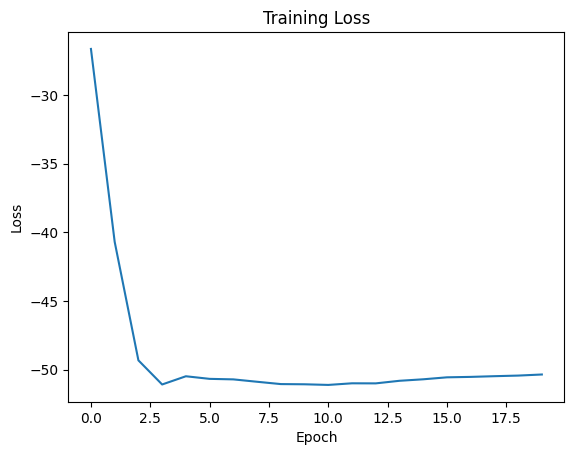

In [45]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


In [46]:
from collections import Counter

model.eval()
phase_counts = Counter()

with torch.no_grad():
    for x, G, H, D in test_loader:
        x = x.to(device)

        y, _ = model(x, hard=True)
        phi = torch.sum(y * theta, dim=2)  # phase angles

        # Flatten batch
        phi_flat = phi.cpu().numpy().flatten()

        # Convert to discrete bins
        for val in phi_flat:
            if np.isclose(val, 0):
                phase_counts["0"] += 1
            elif np.isclose(val, np.pi/2):
                phase_counts["pi/2"] += 1
            elif np.isclose(val, np.pi):
                phase_counts["pi"] += 1
            elif np.isclose(val, 3*np.pi/2):
                phase_counts["3pi/2"] += 1

print("Learned 2-bit Phase Distribution:")
for k, v in phase_counts.items():
    print(f"{k}: {v}")


Learned 2-bit Phase Distribution:
pi/2: 62507
0: 62008
3pi/2: 65327
pi: 66158


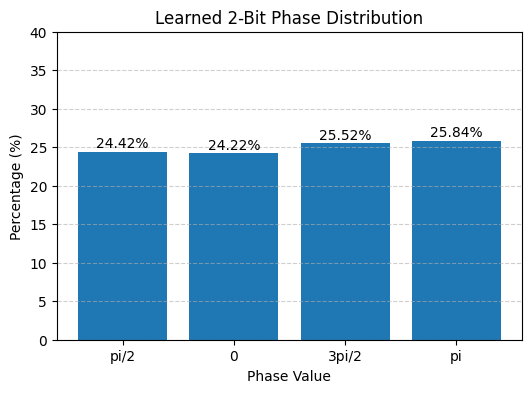

In [48]:
import matplotlib.pyplot as plt

# Convert to percentages
total = sum(phase_counts.values())

labels = list(phase_counts.keys())
percentages = [100 * phase_counts[k] / total for k in labels]

# -----------------------
# BAR PLOT
# -----------------------
plt.figure(figsize=(6,4))
bars = plt.bar(labels, percentages)

plt.title("Learned 2-Bit Phase Distribution")
plt.ylabel("Percentage (%)")
plt.xlabel("Phase Value")

# Add value labels on bars
for i, v in enumerate(percentages):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.ylim(0, 40)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()
